
# Image Filter Analysis using OpenCV

## Overview
This project demonstrates the application of fundamental image processing filters using OpenCV and Python. The program allows users to upload an image and visualize the effects of multiple filtering techniques commonly used in computer vision and digital image processing.

## Filters Implemented

- Averaging Filter
- Gaussian Filter
- Median Filter
- Sharpening Filter
- Laplacian Filter
- Sobel X Edge Detection
- Sobel Y Edge Detection

## Technologies Used

- Python
- OpenCV
- NumPy
- Matplotlib
- Google Colab

## Project Workflow

1. Upload an image.
2. Convert image to RGB and grayscale formats.
3. Apply multiple image enhancement and edge detection filters.
4. Display results for comparison.

## Learning Outcomes

This project demonstrates:

- Image preprocessing techniques
- Noise reduction methods
- Edge detection algorithms
- Image enhancement techniques
- Practical implementation of OpenCV filters

## Installation

```bash
pip install opencv-python numpy matplotlib

Saving image.jpg to image (4).jpg


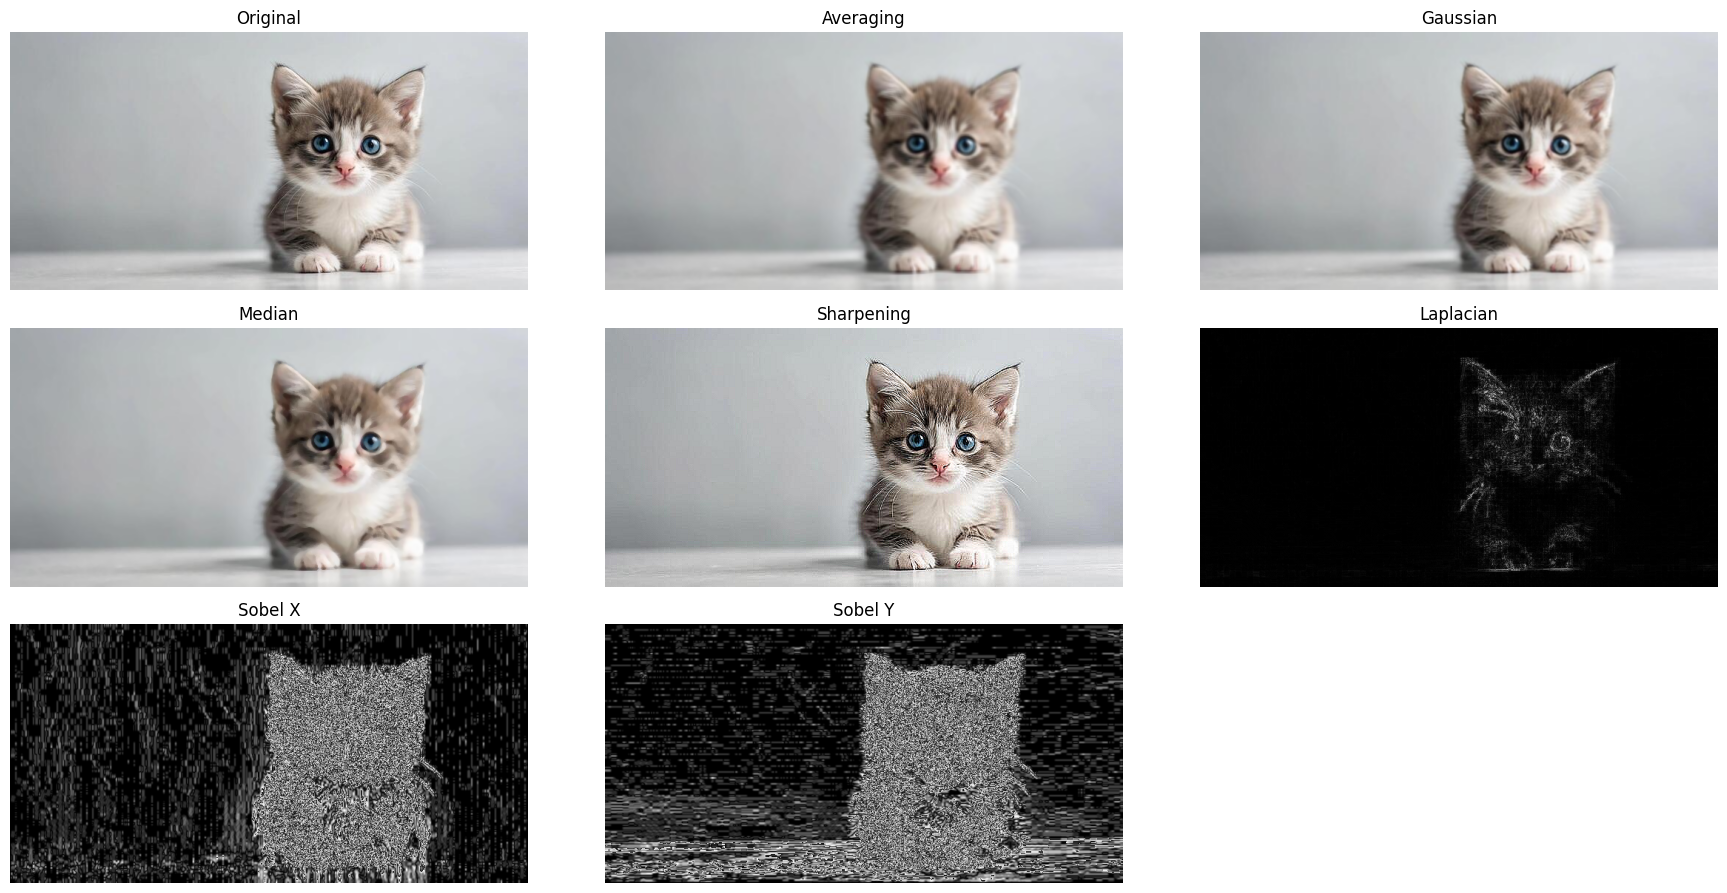

In [5]:
# Install libraries (if needed)
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Step 1: Upload Image
# =========================
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# =========================
# Step 2: Read Image
# =========================
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# =========================
# Step 3: Apply Filters
# =========================

# 1. Averaging Filter
avg_filter = cv2.blur(image_rgb, (5, 5))

# 2. Gaussian Filter
gaussian_filter = cv2.GaussianBlur(image_rgb, (5, 5), 0)

# 3. Median Filter
median_filter = cv2.medianBlur(image_rgb, 5)

# 4. Sharpening Filter
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5,-1],
                           [0, -1, 0]])
sharpen_filter = cv2.filter2D(image_rgb, -1, kernel_sharpen)

# 5. Laplacian Filter
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# 6. Sobel Filters
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

sobel_x = np.uint8(np.absolute(sobel_x))
sobel_y = np.uint8(np.absolute(sobel_y))


# =========================
# Step 4: Display Results
# =========================
titles = [
    "Original", "Averaging", "Gaussian",
    "Median", "Sharpening", "Laplacian",
    "Sobel X", "Sobel Y"
]

images = [
    image_rgb, avg_filter, gaussian_filter,
    median_filter, sharpen_filter, laplacian,
    sobel_x, sobel_y
]

plt.figure(figsize=(18, 12))

for i in range(len(images)):
    plt.subplot(4, 3, i + 1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Saving image.jpg to image (1).jpg


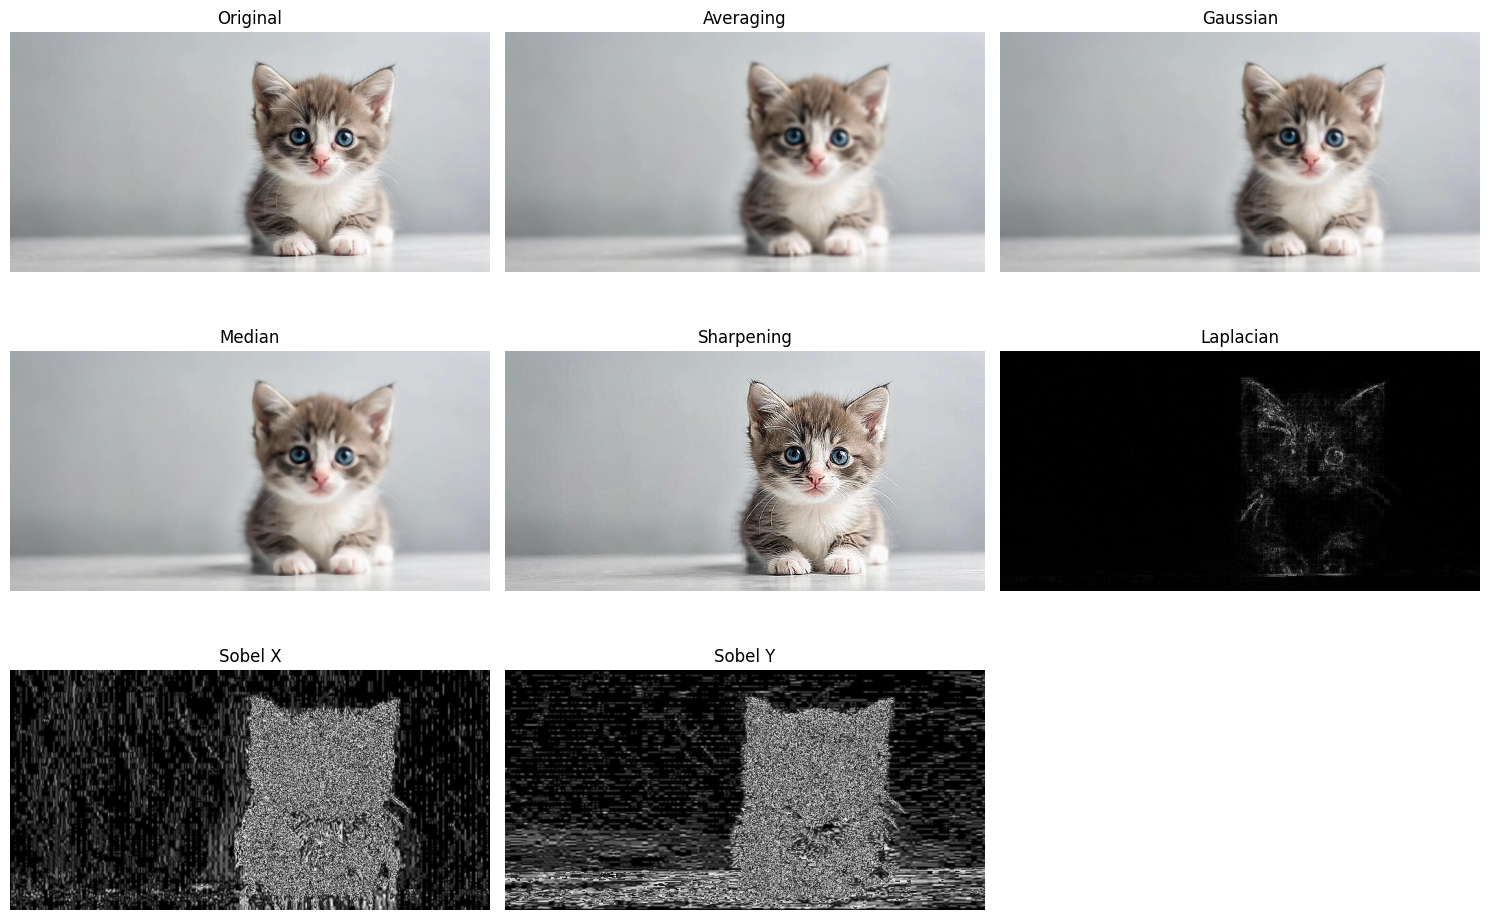

In [2]:
# Install libraries (if needed)
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Filters
avg_filter = cv2.blur(image_rgb, (5, 5))
gaussian_filter = cv2.GaussianBlur(image_rgb, (5, 5), 0)
median_filter = cv2.medianBlur(image_rgb, 5)

kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5,-1],
                           [0, -1, 0]])
sharpen_filter = cv2.filter2D(image_rgb, -1, kernel_sharpen)

laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

sobel_x = np.uint8(np.absolute(sobel_x))
sobel_y = np.uint8(np.absolute(sobel_y))

# Display
titles = [
    "Original", "Averaging", "Gaussian",
    "Median", "Sharpening", "Laplacian",
    "Sobel X", "Sobel Y"
]

images = [
    image_rgb, avg_filter, gaussian_filter,
    median_filter, sharpen_filter, laplacian,
    sobel_x, sobel_y
]

plt.figure(figsize=(15, 10))

for i in range(len(images)):
    plt.subplot(3, 3, i+1)
    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Saving image.jpg to image (2).jpg


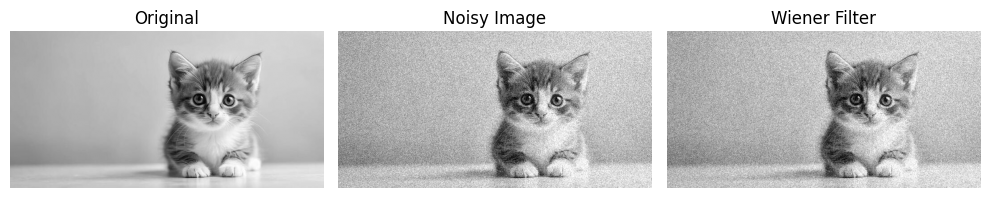

In [3]:
# Install libraries (if needed)
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Add Gaussian noise
noise = np.random.normal(0, 25, gray.shape)
noisy = gray + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

# Wiener filter
def wiener_filter(img, kernel_size=5, noise_var=25):
    img = np.float32(img)
    local_mean = cv2.blur(img, (kernel_size, kernel_size))
    local_var = cv2.blur(img**2, (kernel_size, kernel_size)) - local_mean**2

    result = local_mean + (np.maximum(local_var - noise_var, 0) /
                          (local_var + 1e-5)) * (img - local_mean)
    return np.uint8(result)

wiener = wiener_filter(noisy)

# Display
titles = ["Original", "Noisy Image", "Wiener Filter"]
images = [gray, noisy, wiener]

plt.figure(figsize=(10, 4))

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Saving image.jpg to image (3).jpg


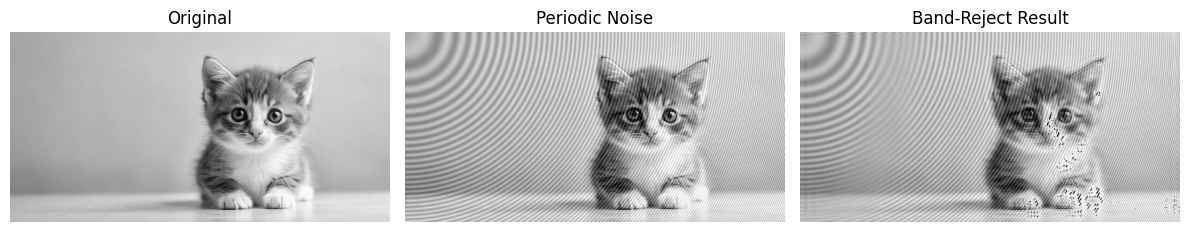

In [4]:
# Install libraries
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# =========================
# Step 1: Add BAND-TYPE (Moire-like) Noise
# =========================
rows, cols = gray.shape
x = np.arange(cols)
y = np.arange(rows)
X, Y = np.meshgrid(x, y)

# Create circular / radial noise (band-like)
noise = 30 * np.sin(2 * np.pi * (X**2 + Y**2) / 5000)

noisy = gray + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

# =========================
# Step 2: Band-Reject Filter (Improved - vectorized)
# =========================
def band_reject_filter(img, D0=50, W=20):
    rows, cols = img.shape
    crow, ccol = rows // 2 , cols // 2

    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)

    u = np.arange(rows)
    v = np.arange(cols)
    U, V = np.meshgrid(u, v, indexing='ij')

    D = np.sqrt((U - crow)**2 + (V - ccol)**2)

    # Gaussian Band-Reject Filter
    H = 1 - np.exp(-((D**2 - D0**2) / (D * W + 1e-5))**2)

    filtered = dft_shift * H
    f_ishift = np.fft.ifftshift(filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    return np.uint8(img_back)

filtered = band_reject_filter(noisy)

# =========================
# Step 3: Display Results
# =========================
titles = ["Original", "Periodic Noise", "Band-Reject Result"]
images = [gray, noisy, filtered]

plt.figure(figsize=(12, 4))

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()